# Gaussian Dots (NN Classification)

In [1]:
import numpy as np  # linear algebra
import matplotlib.pyplot as plt  # plotting
from sklearn.datasets import make_gaussian_quantiles  # generate data

Create the data set.

(1000, 2)
(1000,)


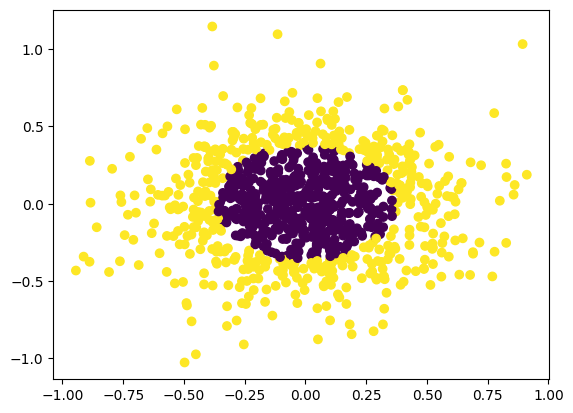

In [2]:
N: int = 1000  # number of samples

data = make_gaussian_quantiles(  # generate data
    cov=0.1,  # covariance (spread)
    n_samples=N,  # number of samples
    n_features=2,  # number of features (dimensions)
    n_classes=2,  # number of classes (labels)
)

X, Y = data  # split data into X and y ( where X is the data and y is the label)
print(X.shape)  # print the shape of X
# (1000, 2) -> 1000 samples with 2 features
print(Y.shape)  # print the shape of y
# (1000,) -> 1000 labels

plt.scatter(  # plot data
    X[:, 0],  # x position of the dots
    X[:, 1],  # y position of the dots
    c=Y,  # color of the dots
)

The NN output must be a probability distribution, so we need to normalize the
data.

Also we need to convert the labels to one-hot encoding. So we need to convert
the labels to integers first.

In [3]:
Y = Y[:, np.newaxis]  # add a new axis to y
print(Y.shape)  # print the shape of y

(1000, 1)


### Activation Functions

In [4]:
def sigmoid(x: np.ndarray, derivative: bool = False) -> np.ndarray:
    """Sigmoid function"""
    return x * (1 - x) if derivative else 1 / (1 + np.exp(-x))


def relu(x: np.ndarray, derivative: bool = False) -> np.ndarray:
    """ReLU function"""
    # return 1 * (x > 0) if derivative else x * (x > 0)
    if derivative:
        x[x <= 0] = 0
        x[x > 0] = 1
        return x
    else:
        return np.maximum(0, x)


def tanh(x: np.ndarray, derivative: bool = False) -> np.ndarray:
    """Tanh function"""
    return 1 - x**2 if derivative else np.tanh(x)

### Loss Functions

In [5]:
def mean_squared_error(y, y_pred, derivative: bool = False) -> np.ndarray:
    """Mean Squared Error function"""
    return (y_pred - y) if derivative else np.mean((y_pred - y) ** 2)

## Create the NN Structure

In [6]:
def initialize_parameters(layer_dimensions: list) -> dict:
    """
    Initialize parameters of the Hidden Layers
    """
    parameters = {}  # create an empty dictionary
    for l in range(0, len(layer_dimensions) - 1):  # iterate over the number of layers
        parameters["W" + str(l + 1)] = np.random.randn(
            layer_dimensions[l], layer_dimensions[l + 1]
        )  # create a matrix of random numbers
        parameters["b" + str(l + 1)] = np.random.randn(
            1, layer_dimensions[l + 1]
        )  # create a vector of zeros
    return parameters

In [7]:
layer_dims = [2, 4, 8, 1]
params = initialize_parameters(layer_dims)
params;

{'W1': array([[-1.2222361 , -0.86566722,  0.24515583,  0.26711682],
        [-1.09131914,  1.01810583, -0.55618986, -0.22465534]]),
 'b1': array([[-0.99496057,  0.17445488, -1.03366817,  0.55194521]]),
 'W2': array([[ 1.41225142,  1.3260419 , -0.69746233,  0.15630959, -0.13253585,
          0.19278905, -0.05010437,  0.01616641],
        [-0.37043879,  0.51947264, -0.16750372, -0.19252449,  0.25838828,
          0.97870208,  0.90570249, -0.8732028 ],
        [-0.53980934,  0.48784484, -2.03340731, -0.2980467 ,  0.39497805,
         -0.27737086,  0.91246385,  0.42704757],
        [ 0.06065021, -1.21645943, -1.28767875, -0.21082137,  0.57576225,
          0.51314359, -1.41040274,  0.07314773]]),
 'b2': array([[ 4.83772275e-01,  1.98514904e+00,  7.03065433e-01,
         -4.65356346e-01, -1.69424817e+00,  3.31270053e-01,
          1.53034533e+00,  1.17383114e-03]]),
 'W3': array([[-0.78616202],
        [-1.25277504],
        [-0.49015086],
        [ 0.29215341],
        [-0.05457818],
     

## Training

In [8]:
print("X", X.shape)  # 1000 samples with 2 features

for key, value in params.items():
    print(key, value.shape)

X (1000, 2)
W1 (2, 4)
b1 (1, 4)
W2 (4, 8)
b2 (1, 8)
W3 (8, 1)
b3 (1, 1)


In [9]:
def train_model(
    X: np.ndarray, parameters: dict, lr: float = 0.001, training: bool = True
) -> np.ndarray:
    """
    Train the Neural Network
    """

    # Forward propagation
    parameters["A0"] = X  # put the data into the input layer

    parameters["Z1"] = parameters["A0"] @ parameters["W1"] + parameters["b1"]
    parameters["A1"] = relu(parameters["Z1"])  # apply the activation function

    parameters["Z2"] = parameters["A1"] @ parameters["W2"] + parameters["b2"]
    parameters["A2"] = relu(parameters["Z2"])  # apply the activation function

    parameters["Z3"] = parameters["A2"] @ parameters["W3"] + parameters["b3"]
    parameters["A3"] = sigmoid(parameters["Z3"])  # apply the activation function

    output: np.ndarray = parameters["A3"]  # get the output of the network
    # print(output)  # print the shape of the output

    if training:
        # # Backward propagation
        # # calculate the error of the output layer
        parameters["dZ3"] = mean_squared_error(Y, output, derivative=True) * sigmoid(
            parameters["A3"], derivative=True
        )
        parameters["dW3"] = parameters["A2"].T @ parameters["dZ3"]

        parameters["dZ2"] = (
            parameters["dZ3"]
            @ parameters["W3"].T
            * relu(parameters["A2"], derivative=True)
        )
        parameters["dW2"] = parameters["A1"].T @ parameters["dZ2"]

        parameters["dZ1"] = (
            parameters["dZ2"]
            @ parameters["W2"].T
            * relu(parameters["A1"], derivative=True)
        )
        parameters["dW1"] = parameters["A0"].T @ parameters["dZ1"]

        # # Gradient Descent
        # # update the parameters of the network
        parameters["W3"] -= lr * parameters["dW3"]  # update the weights
        parameters["b3"] -= lr * np.sum(
            parameters["dZ3"], axis=0, keepdims=True
        )  # update the bias
        parameters["W2"] -= lr * parameters["dW2"]  # update the weights
        parameters["b2"] -= lr * np.sum(
            parameters["dZ2"], axis=0, keepdims=True
        )  # update the bias
        parameters["W1"] -= lr * parameters["dW1"]  # update the weights
        parameters["b1"] -= lr * np.sum(
            parameters["dZ1"], axis=0, keepdims=True
        )  # update the bias

    return output  # return the output of the network

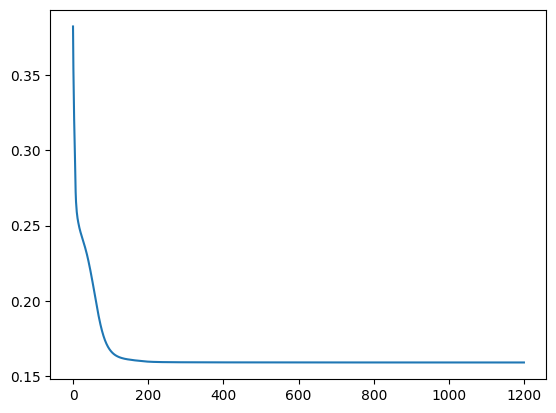

In [10]:
layer_dims = [
    2,
    4,
    8,
    1,
]  # define the number of layers and the number of neurons in each layer
params = initialize_parameters(layer_dims)  # initialize the parameters of the network
errors = []  # create an empty list to store the errors
epochs: int = 30000  # number of epochs

for _ in range(epochs):  # iterate over the number of epochs
    output = train_model(X, parameters=params, lr=0.0001)  # train the network
    if _ % 25 == 0:  # print the error every 100 epochs
        # print(f"Loss after iteration {_}: {mean_squared_error(Y, output)}")  # print the error
        errors.append(mean_squared_error(Y, output))  # append the error to the list

plt.plot(errors)  # plot the errors

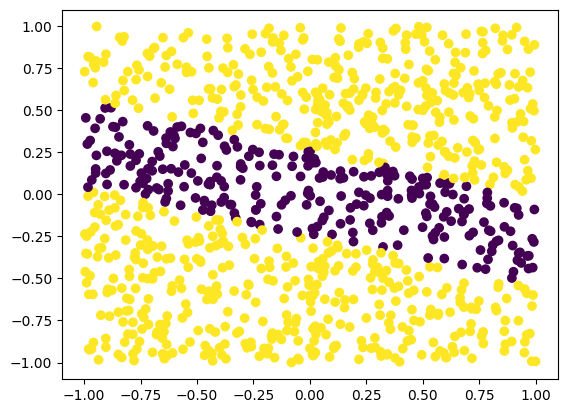

In [11]:
data_test = (np.random.rand(1000, 2) * 2) - 1  # create 1000 samples with 2 features

y = train_model(
    data_test, parameters=params, training=False
)  # get the output of the network
y = np.where(y >= 0.5, 1, 0)  # apply a threshold to the output
plt.scatter(data_test[:, 0], data_test[:, 1], c=y)  # plot the data